# Introduction: Euclid as a Route Into Modern Geometry

Source orientation: *Euclid and Beyond*, Introduction, printed pp. 1-6 / PDF pp. 13-18. The PDF is image-based and was used only to orient the agenda of this notebook. No source page images, crops, layout, or textbook prose are reproduced here.

## Chapter Question

How does a course that begins with Euclid turn into a modern geometry course about axioms, algebra, models, and invariants?

## Chapter Goal

By the end of this notebook, you should be able to read the Introduction as a route map. Euclid supplies construction problems and proof ambitions; modern geometry asks what assumptions make those constructions legal, what algebra appears when lengths are coordinated, what field extensions permit or forbid constructions, what area means without numerical measurement, why the parallel postulate opens the door to hyperbolic models, and how polyhedra bring combinatorics and topology into the same story.

This is an orientation notebook, so the visuals are deliberately wide-angle. Each artifact gives an inspectable model of a theme that later chapters will slow down and prove.

## Computational Translation Guide

| Book-side theme | Computational representation in this notebook | What to inspect |
| --- | --- | --- |
| Ruler-and-compass construction | Points, circles, intersections, and exact distance checks | Which existence assumption makes the construction finish |
| Axiomatic method | A directed dependency graph of objects, assumptions, and conclusions | Which nodes are data, which are rules, and which are inferred |
| Geometry without numbers | Equivalence classes and invariants, then optional coordinates for checking | Whether a computed number is the idea itself or only a diagnostic |
| Coordinates and fields | Ordered pairs over a field and algebraic closure operations | Where arithmetic enters a synthetic-looking claim |
| Constructibility | Degrees of field extensions and the power-of-two obstruction | Why some regular polygons are possible and others are not |
| Area | Polygon area as a preserved quantity under decomposition | Why a Pythagorean statement can be read as an area identity |
| Hyperbolic geometry | The Poincare disk model with geodesics represented by orthogonal arcs | How many parallels through one point can avoid a given line |
| Polyhedra | Face-edge-vertex data and mesh diagnostics | Which counts survive as Euler characteristic |

## Route

1. Build a concept map for the full Euclid-to-modern course arc.
2. Reconstruct the first construction style as exact data and expose the hidden intersection assumption.
3. Translate coordinates and constructibility into field-degree tests.
4. Treat area as an invariant rather than a synonym for a real number.
5. Use the Poincare disk to see why the parallel postulate is not just a local drawing habit.
6. Treat polyhedra as finite incidence data whose checks can be automated.
7. Run a small applied lab and final sanity checks that tie the artifacts back to the source span.

In [1]:
from pathlib import Path
import sys
import json
import math

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Euclid and Beyond book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = "introduction"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURE_DIR = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
for directory in [FIGURE_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import sympy as sp
import networkx as nx
import plotly.graph_objects as go
import trimesh

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, FancyArrowPatch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from utils.artifacts import assert_artifact, display_artifact

artifacts = {}
check_data = {}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titleweight": "bold",
})

def book_relative(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def save_figure(fig, filename, dpi=170):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return path

def write_json(data, filename):
    path = CHECK_DIR / filename
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path

def polygon_area(points):
    pts = np.asarray(points, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifact root: {book_relative(UNIT_ARTIFACT_ROOT)}")

Book root: Euclid-and-Beyond
Artifact root: artifacts/introduction


## 1. Course Arc as a Concept Map

The Introduction is not only historical framing. It announces a sequence of mathematical upgrades: constructions become proof obligations, proof obligations require explicit axioms, axioms invite models, and models expose algebraic and topological invariants. The concept map below is a dependency map, not a decoration. Inspect the arrows: each arrow says what kind of question forces the course to move to the next theme.

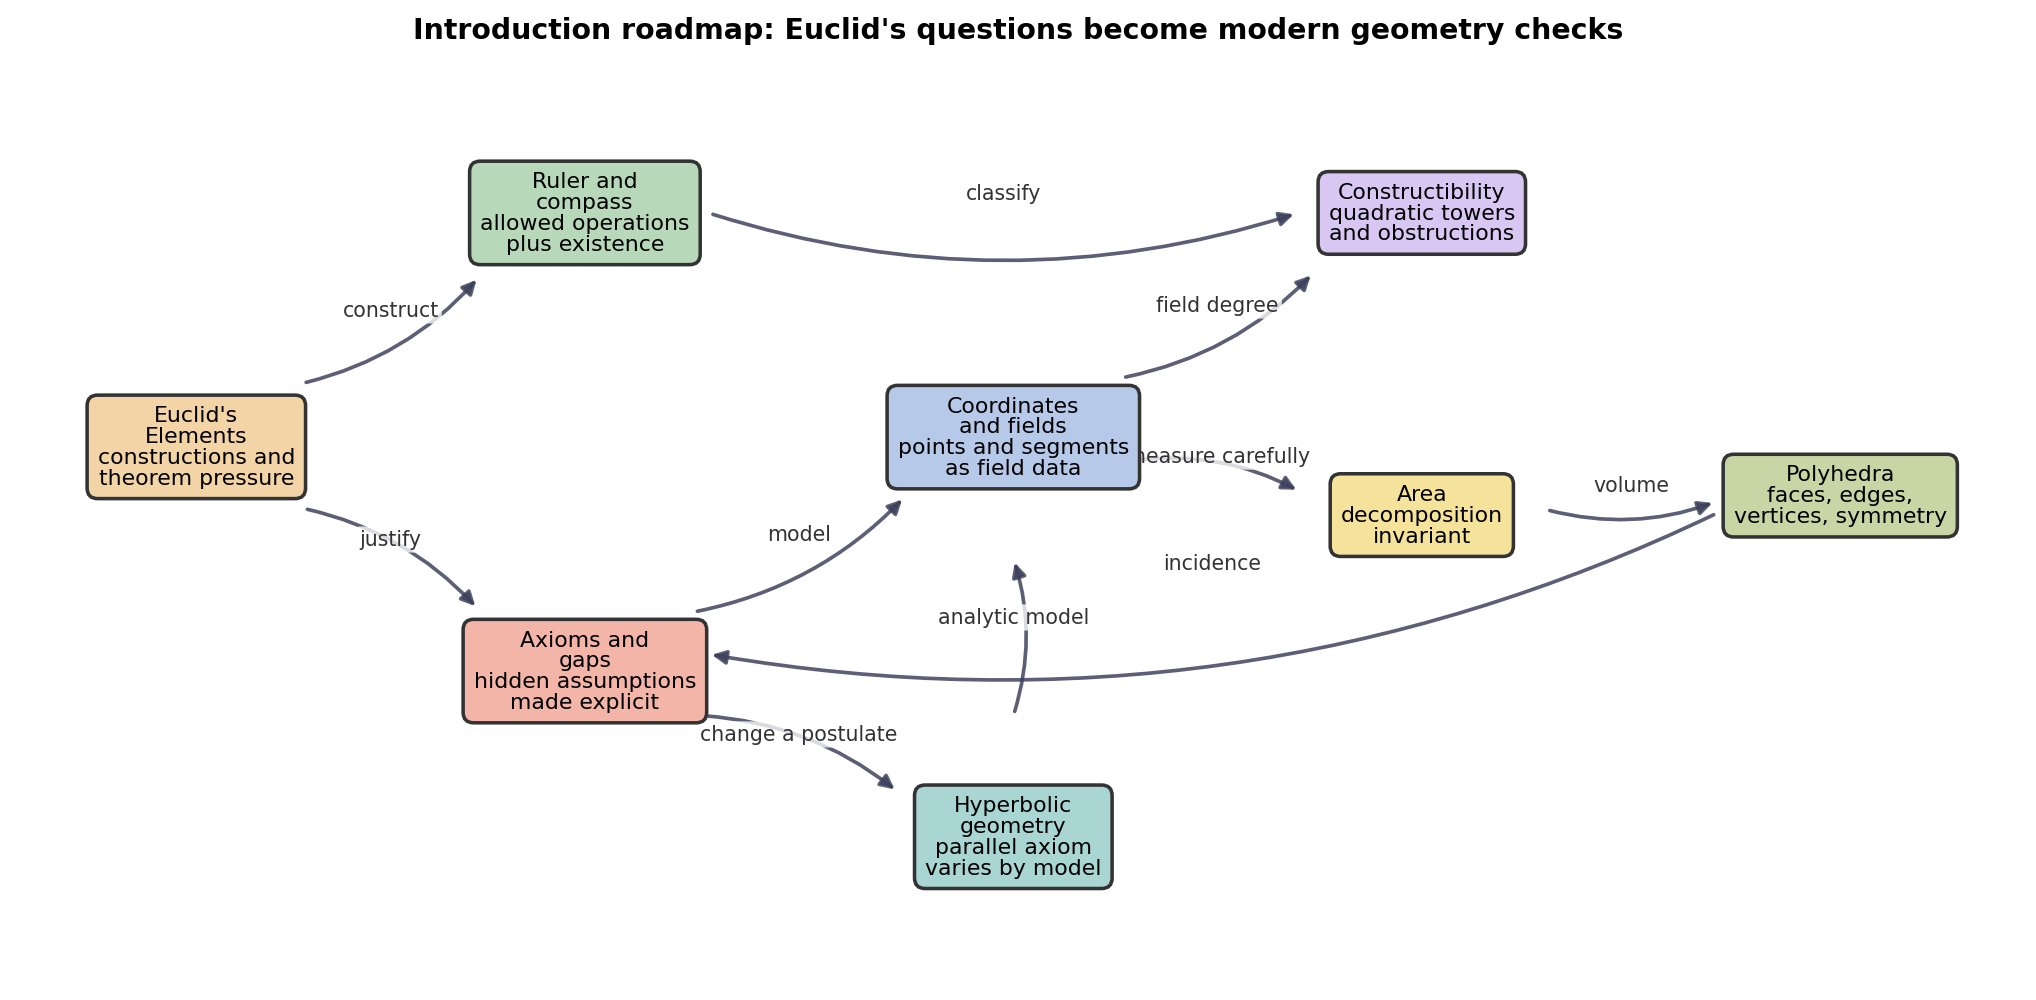

{'node_count': 8,
 'edge_count': 10,
 'required_topics_present': ['Area',
  'Axioms and gaps',
  'Constructibility',
  'Coordinates and fields',
  "Euclid's Elements",
  'Hyperbolic geometry',
  'Polyhedra',
  'Ruler and compass'],
 'all_required_topics_present': True,
 'all_topics_reachable_from_euclid': True}

In [2]:
course_nodes = {
    "Euclid's Elements": "constructions and\ntheorem pressure",
    "Ruler and compass": "allowed operations\nplus existence",
    "Axioms and gaps": "hidden assumptions\nmade explicit",
    "Coordinates and fields": "points and segments\nas field data",
    "Constructibility": "quadratic towers\nand obstructions",
    "Area": "decomposition\ninvariant",
    "Hyperbolic geometry": "parallel axiom\nvaries by model",
    "Polyhedra": "faces, edges,\nvertices, symmetry",
}
course_edges = [
    ("Euclid's Elements", "Ruler and compass", "construct"),
    ("Euclid's Elements", "Axioms and gaps", "justify"),
    ("Axioms and gaps", "Coordinates and fields", "model"),
    ("Ruler and compass", "Constructibility", "classify"),
    ("Coordinates and fields", "Constructibility", "field degree"),
    ("Coordinates and fields", "Area", "measure carefully"),
    ("Axioms and gaps", "Hyperbolic geometry", "change a postulate"),
    ("Area", "Polyhedra", "volume"),
    ("Hyperbolic geometry", "Coordinates and fields", "analytic model"),
    ("Polyhedra", "Axioms and gaps", "incidence"),
]
G = nx.DiGraph()
for node, label in course_nodes.items():
    G.add_node(node, label=label)
for u, v, label in course_edges:
    G.add_edge(u, v, label=label)

pos = {
    "Euclid's Elements": (0.0, 0.0),
    "Ruler and compass": (1.95, 1.2),
    "Axioms and gaps": (1.95, -1.15),
    "Coordinates and fields": (4.1, 0.05),
    "Constructibility": (6.15, 1.2),
    "Area": (6.15, -0.35),
    "Hyperbolic geometry": (4.1, -2.0),
    "Polyhedra": (8.25, -0.25),
}
node_titles = {
    "Euclid's Elements": "Euclid's\nElements",
    "Ruler and compass": "Ruler and\ncompass",
    "Axioms and gaps": "Axioms and\ngaps",
    "Coordinates and fields": "Coordinates\nand fields",
    "Constructibility": "Constructibility",
    "Area": "Area",
    "Hyperbolic geometry": "Hyperbolic\ngeometry",
    "Polyhedra": "Polyhedra",
}
node_colors = {
    "Euclid's Elements": "#f3d4a6",
    "Ruler and compass": "#b8d8ba",
    "Axioms and gaps": "#f2b5a8",
    "Coordinates and fields": "#b7c9e8",
    "Constructibility": "#d8c7f2",
    "Area": "#f5e39b",
    "Hyperbolic geometry": "#a9d6d3",
    "Polyhedra": "#c8d6a6",
}

fig, ax = plt.subplots(figsize=(15.2, 7.0))
ax.set_xlim(-0.9, 9.15)
ax.set_ylim(-2.75, 1.95)
ax.axis("off")

def trimmed_edge(u, v, trim=0.62):
    start = np.array(pos[u], dtype=float)
    end = np.array(pos[v], dtype=float)
    direction = end - start
    length = np.linalg.norm(direction)
    if length == 0:
        return start, end
    unit = direction / length
    return start + trim * unit, end - trim * unit

for u, v, data in G.edges(data=True):
    p1, p2 = trimmed_edge(u, v)
    y1, y2 = pos[u][1], pos[v][1]
    rad = 0.16 if y2 >= y1 else -0.16
    arrow = FancyArrowPatch(p1, p2, connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>", mutation_scale=12, linewidth=1.55, color="#3d405b", alpha=0.84)
    ax.add_patch(arrow)
    mx, my = (p1 + p2) / 2
    ax.text(mx, my + 0.1, data["label"], ha="center", va="center", fontsize=8.7, color="#333333", bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "edgecolor": "none", "alpha": 0.78})

for node, (x, y) in pos.items():
    text = f"{node_titles[node]}\n{course_nodes[node]}"
    ax.text(x, y, text, ha="center", va="center", fontsize=9.3, linespacing=1.05, bbox={"boxstyle": "round,pad=0.48", "facecolor": node_colors[node], "edgecolor": "#333333", "linewidth": 1.5})

ax.set_title("Introduction roadmap: Euclid's questions become modern geometry checks", pad=12)
course_map_path = save_figure(fig, "course-roadmap.png")
artifacts["course_map"] = course_map_path
required_topics = set(course_nodes)
course_check = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "required_topics_present": sorted(required_topics),
    "all_required_topics_present": required_topics.issubset(G.nodes),
    "all_topics_reachable_from_euclid": all(nx.has_path(G, "Euclid's Elements", node) for node in G.nodes if node != "Euclid's Elements"),
}
check_data["course_map"] = course_check
write_json(course_check, "course-map-checks.json")
display_artifact(course_map_path, width=980)
course_check


## 2. Constructions Need Existence Claims

A construction problem is executable only after its allowed operations and existence assumptions are explicit. The equilateral triangle construction is the right small test case: two circles are easy to draw from a segment, but the proof still needs the assertion that the circles actually meet in the desired plane region. Later chapters revisit this gap with more formal axioms.

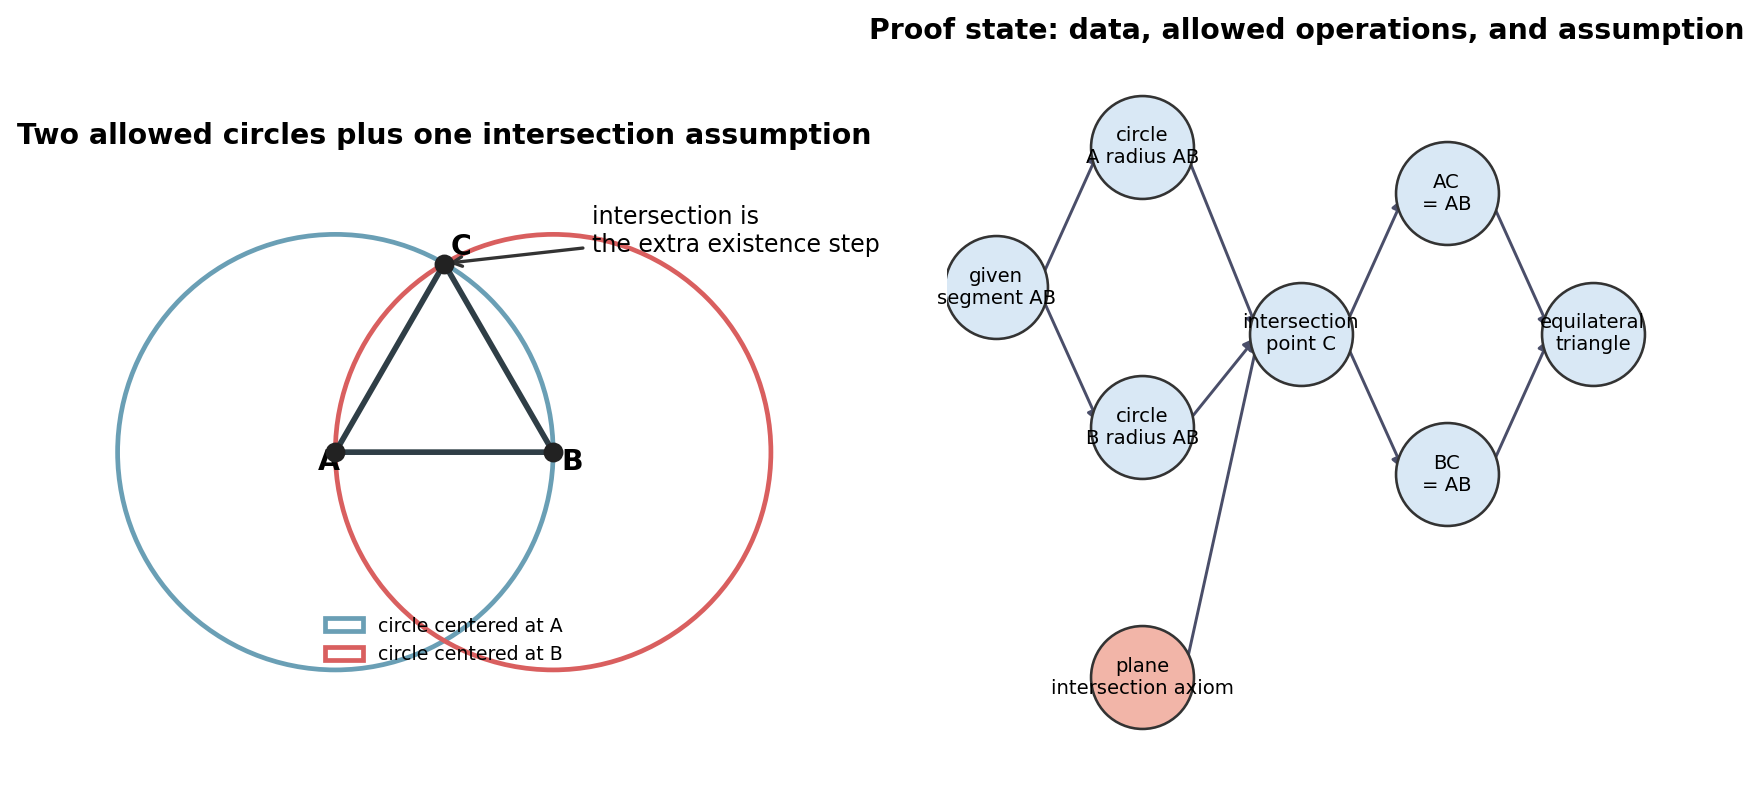

{'lengths': {'AB': '1', 'AC': '1', 'BC': '1'},
 'all_three_lengths_equal': True,
 'circle_intersection_condition': True,
 'dependency_nodes': 8,
 'dependency_edges': 9}

In [3]:
sqrt3 = sp.sqrt(3)
A = sp.Matrix([0, 0])
B = sp.Matrix([1, 0])
C = sp.Matrix([sp.Rational(1, 2), sqrt3 / 2])

def exact_distance(P, Q):
    return sp.sqrt(sum((P[i] - Q[i]) ** 2 for i in range(2)))

lengths = {
    "AB": sp.simplify(exact_distance(A, B)),
    "AC": sp.simplify(exact_distance(A, C)),
    "BC": sp.simplify(exact_distance(B, C)),
}
intersection_condition = abs(float(lengths["AB"])) <= 1 + 1 and abs(float(lengths["AB"])) >= abs(1 - 1)

fig = plt.figure(figsize=(12, 5.6))
left = fig.add_subplot(1, 2, 1)
right = fig.add_subplot(1, 2, 2)
for center, color, label in [((0, 0), "#6a9fb5", "circle centered at A"), ((1, 0), "#d95f5f", "circle centered at B")]:
    left.add_patch(Circle(center, 1.0, fill=False, linewidth=2.0, edgecolor=color, label=label))
triangle = np.array([[0, 0], [1, 0], [0.5, float(sp.sqrt(3) / 2)], [0, 0]])
left.plot(triangle[:, 0], triangle[:, 1], color="#2f3e46", linewidth=2.4)
left.scatter([0, 1, 0.5], [0, 0, float(sp.sqrt(3) / 2)], s=55, color="#222222", zorder=5)
for label, point, offset in [("A", (0, 0), (-0.08, -0.08)), ("B", (1, 0), (0.04, -0.08)), ("C", (0.5, float(sp.sqrt(3) / 2)), (0.03, 0.04))]:
    left.text(point[0] + offset[0], point[1] + offset[1], label, fontsize=12, weight="bold")
left.annotate("intersection is\nthe extra existence step", xy=(0.5, float(sp.sqrt(3) / 2)), xytext=(1.18, 0.92), arrowprops={"arrowstyle": "->", "linewidth": 1.4, "color": "#333333"}, fontsize=10)
left.set_aspect("equal")
left.set_xlim(-1.15, 2.15)
left.set_ylim(-1.05, 1.35)
left.set_title("Two allowed circles plus one intersection assumption")
left.legend(loc="lower center", fontsize=8, frameon=False)
left.axis("off")

D = nx.DiGraph()
dependency_edges = [
    ("given segment AB", "circle A radius AB"),
    ("given segment AB", "circle B radius AB"),
    ("circle A radius AB", "intersection point C"),
    ("circle B radius AB", "intersection point C"),
    ("plane intersection axiom", "intersection point C"),
    ("intersection point C", "AC = AB"),
    ("intersection point C", "BC = AB"),
    ("AC = AB", "equilateral triangle"),
    ("BC = AB", "equilateral triangle"),
]
D.add_edges_from(dependency_edges)
dep_pos = {
    "given segment AB": (0, 0.7),
    "circle A radius AB": (1.2, 1.15),
    "circle B radius AB": (1.2, 0.25),
    "plane intersection axiom": (1.2, -0.55),
    "intersection point C": (2.5, 0.55),
    "AC = AB": (3.7, 1.0),
    "BC = AB": (3.7, 0.1),
    "equilateral triangle": (4.9, 0.55),
}
right.axis("off")
right.set_xlim(-0.4, 5.5)
right.set_ylim(-0.9, 1.45)
for u, v in D.edges:
    x1, y1 = dep_pos[u]
    x2, y2 = dep_pos[v]
    right.add_patch(FancyArrowPatch((x1 + 0.34, y1), (x2 - 0.34, y2), arrowstyle="-|>", mutation_scale=11, linewidth=1.25, color="#4a4e69"))
for node, (x, y) in dep_pos.items():
    color = "#f2b5a8" if "axiom" in node else "#d9e8f5"
    right.scatter([x], [y], s=1900, color=color, edgecolor="#333333", linewidth=1.1, zorder=3)
    right.text(x, y, node.replace(" ", "\n", 1), ha="center", va="center", fontsize=8.3, zorder=4)
right.set_title("Proof state: data, allowed operations, and assumption")

construction_path = save_figure(fig, "equilateral-construction-assumption.png")
artifacts["construction_assumption"] = construction_path
construction_check = {
    "lengths": {key: str(value) for key, value in lengths.items()},
    "all_three_lengths_equal": bool(lengths["AB"] == lengths["AC"] == lengths["BC"]),
    "circle_intersection_condition": bool(intersection_condition),
    "dependency_nodes": D.number_of_nodes(),
    "dependency_edges": D.number_of_edges(),
}
check_data["construction_assumption"] = construction_check
write_json(construction_check, "construction-assumption-checks.json")
display_artifact(construction_path, width=980)
construction_check

## 3. Coordinates, Fields, and Constructibility

The Introduction stresses that Euclid often reasons without numerical length, while modern geometry can deliberately introduce coordinates. Once a line segment can be treated arithmetically, ruler-and-compass constructions translate into field operations: addition, subtraction, multiplication, division, and square roots. That translation explains why some construction problems succeed and others cannot be done with the original tools.

The chart below uses regular polygons as a compact diagnostic. For a regular `n`-gon, the relevant degree is `phi(n)`. A power of two is the signature of a quadratic tower; a non-power of two flags an obstruction for straightedge and compass.

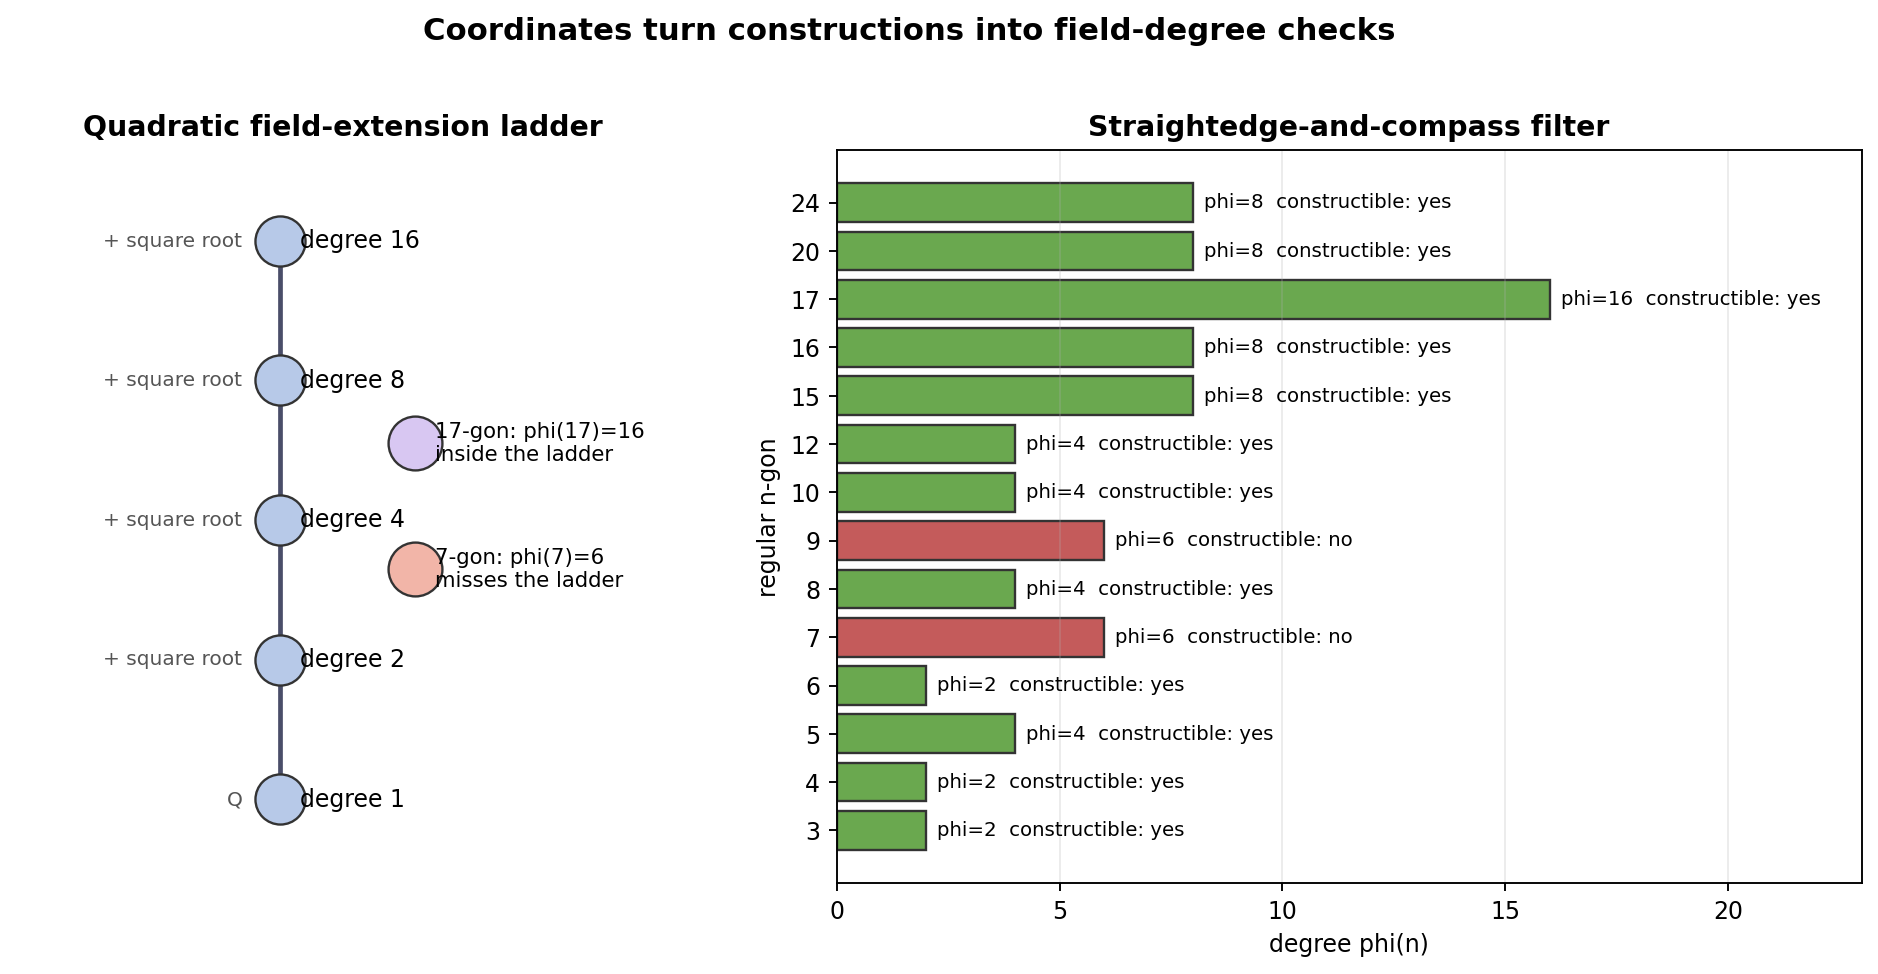

,n,phi_n,power_of_two_degree,factorization
0,3,2,True,{3: 1}
1,4,2,True,{2: 2}
2,5,4,True,{5: 1}
3,6,2,True,"{2: 1, 3: 1}"
4,7,6,False,{7: 1}
5,8,4,True,{2: 3}
6,9,6,False,{3: 2}
7,10,4,True,"{2: 1, 5: 1}"
8,12,4,True,"{2: 2, 3: 1}"
9,15,8,True,"{3: 1, 5: 1}"


In [4]:
def is_power_of_two(value):
    value = int(value)
    return value > 0 and (value & (value - 1)) == 0

polygon_ns = [3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 16, 17, 20, 24]
construct_rows = []
for n in polygon_ns:
    degree = int(sp.totient(n))
    construct_rows.append({
        "n": n,
        "phi_n": degree,
        "power_of_two_degree": is_power_of_two(degree),
        "factorization": str(sp.factorint(n)),
    })
constructibility_table = pd.DataFrame(construct_rows)

fig, (ax_ladder, ax_bar) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.05, 1.65]})
powers = [1, 2, 4, 8, 16]
y = np.arange(len(powers))
ax_ladder.plot([0] * len(powers), y, color="#4a4e69", linewidth=2)
ax_ladder.scatter([0] * len(powers), y, s=450, color="#b7c9e8", edgecolor="#333333", zorder=3)
for yi, degree in zip(y, powers):
    ax_ladder.text(0.12, yi, f"degree {degree}", va="center", fontsize=10)
    ax_ladder.text(-0.22, yi, "Q" if degree == 1 else "+ square root", ha="right", va="center", fontsize=8.5, color="#555555")
ax_ladder.scatter([0.8], [2.55], s=520, color="#d8c7f2", edgecolor="#333333")
ax_ladder.text(0.92, 2.55, "17-gon: phi(17)=16\ninside the ladder", va="center", fontsize=9)
ax_ladder.scatter([0.8], [1.65], s=520, color="#f2b5a8", edgecolor="#333333")
ax_ladder.text(0.92, 1.65, "7-gon: phi(7)=6\nmisses the ladder", va="center", fontsize=9)
ax_ladder.set_xlim(-1.55, 2.3)
ax_ladder.set_ylim(-0.6, len(powers) - 0.35)
ax_ladder.set_title("Quadratic field-extension ladder")
ax_ladder.axis("off")

colors = ["#6aa84f" if ok else "#c45b5b" for ok in constructibility_table["power_of_two_degree"]]
ax_bar.barh(constructibility_table["n"].astype(str), constructibility_table["phi_n"], color=colors, edgecolor="#333333")
for idx, row in constructibility_table.iterrows():
    status = "yes" if row["power_of_two_degree"] else "no"
    ax_bar.text(row["phi_n"] + 0.25, idx, f"phi={row['phi_n']}  constructible: {status}", va="center", fontsize=8.4)
ax_bar.set_xlabel("degree phi(n)")
ax_bar.set_ylabel("regular n-gon")
ax_bar.set_title("Straightedge-and-compass filter")
ax_bar.set_xlim(0, max(constructibility_table["phi_n"]) + 7)
ax_bar.grid(axis="x", alpha=0.25)
fig.suptitle("Coordinates turn constructions into field-degree checks", y=1.02, fontsize=13, weight="bold")
constructibility_path = save_figure(fig, "constructibility-field-ladder.png")
artifacts["constructibility_ladder"] = constructibility_path

table_path = TABLE_DIR / "constructibility-summary.csv"
constructibility_table.to_csv(table_path, index=False)
artifacts["constructibility_table"] = table_path
constructibility_check = {
    "regular_17_gon_constructible": bool(constructibility_table.loc[constructibility_table["n"] == 17, "power_of_two_degree"].iloc[0]),
    "regular_7_gon_constructible": bool(constructibility_table.loc[constructibility_table["n"] == 7, "power_of_two_degree"].iloc[0]),
    "all_constructible_entries_have_power_of_two_degree": bool(constructibility_table[constructibility_table["power_of_two_degree"]]["phi_n"].map(is_power_of_two).all()),
    "nonconstructible_examples": constructibility_table.loc[~constructibility_table["power_of_two_degree"], "n"].astype(int).tolist(),
}
check_data["constructibility"] = constructibility_check
write_json(constructibility_check, "constructibility-checks.json")
display_artifact(constructibility_path, width=980)
constructibility_table


## 4. Area Is an Invariant Before It Is a Number

The Introduction points out a subtle shift: Euclid can compare figures without first assigning every length or area a real number. A computational notebook has to introduce numbers in order to check itself, but the check should respect the geometric idea. In the next artifact, the right triangle is not the theorem by itself. The invariant is the equality of the two smaller square areas with the large square area.

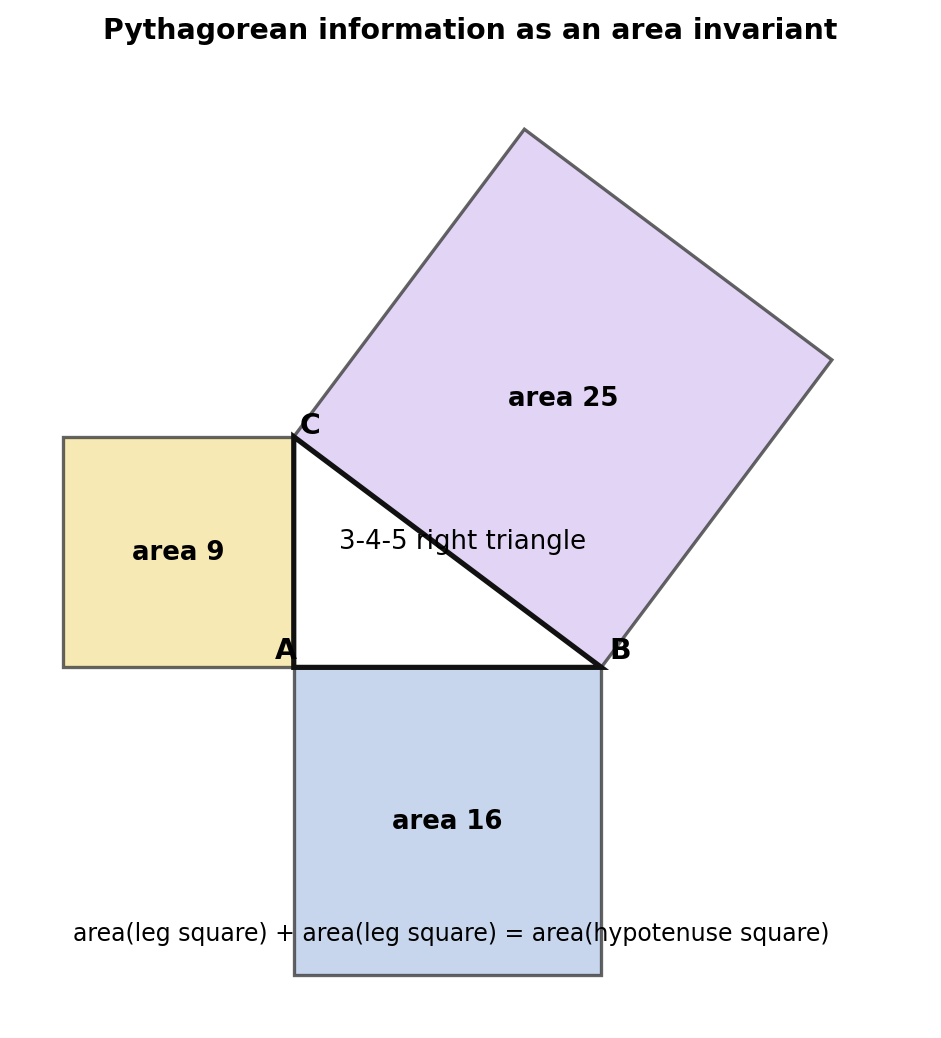

{'base_square_area': np.float64(16.0),
 'height_square_area': np.float64(9.0),
 'hypotenuse_square_area': np.float64(25.0),
 'area_identity_holds': True,
 'symbolic_identity': 'True'}

In [5]:
A2 = np.array([0.0, 0.0])
B2 = np.array([4.0, 0.0])
C2 = np.array([0.0, 3.0])

def square_on_segment(P, Q, side="left"):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    v = Q - P
    perp = np.array([-v[1], v[0]])
    if side == "right":
        perp = -perp
    return np.array([P, Q, Q + perp, P + perp])

base_square = square_on_segment(A2, B2, side="right")
height_square = square_on_segment(C2, A2, side="right")
hyp_square = square_on_segment(B2, C2, side="right")
triangle = np.array([A2, B2, C2])
areas = {
    "base_square": polygon_area(base_square),
    "height_square": polygon_area(height_square),
    "hypotenuse_square": polygon_area(hyp_square),
    "triangle": polygon_area(triangle),
}

fig, ax = plt.subplots(figsize=(8.6, 7.4))
for pts, color, label in [
    (base_square, "#b7c9e8", "area 16"),
    (height_square, "#f5e39b", "area 9"),
    (hyp_square, "#d8c7f2", "area 25"),
]:
    ax.add_patch(Polygon(pts, closed=True, facecolor=color, edgecolor="#333333", linewidth=1.4, alpha=0.76))
    centroid = pts.mean(axis=0)
    ax.text(centroid[0], centroid[1], label, ha="center", va="center", fontsize=11, weight="bold")
ax.add_patch(Polygon(triangle, closed=True, facecolor="#ffffff", edgecolor="#111111", linewidth=2.2))
for label, point, offset in [("A", A2, (-0.25, 0.12)), ("B", B2, (0.1, 0.12)), ("C", C2, (0.08, 0.05))]:
    ax.text(point[0] + offset[0], point[1] + offset[1], label, fontsize=12, weight="bold")
ax.text(2.2, 1.55, "3-4-5 right triangle", fontsize=11, ha="center")
ax.text(2.05, -3.55, "area(leg square) + area(leg square) = area(hypotenuse square)", ha="center", fontsize=10)
ax.set_aspect("equal")
ax.set_xlim(-3.6, 8.2)
ax.set_ylim(-4.6, 8.0)
ax.axis("off")
ax.set_title("Pythagorean information as an area invariant")
area_path = save_figure(fig, "area-as-invariant.png")
artifacts["area_invariant"] = area_path
area_identity = sp.Eq(sp.Integer(3) ** 2 + sp.Integer(4) ** 2, sp.Integer(5) ** 2)
area_check = {
    "base_square_area": areas["base_square"],
    "height_square_area": areas["height_square"],
    "hypotenuse_square_area": areas["hypotenuse_square"],
    "area_identity_holds": bool(abs(areas["base_square"] + areas["height_square"] - areas["hypotenuse_square"]) < 1e-12),
    "symbolic_identity": str(area_identity),
}
check_data["area_invariant"] = area_check
write_json(area_check, "area-checks.json")
display_artifact(area_path, width=760)
area_check

## 5. Hyperbolic Geometry as a Model Check

The source span frames the parallel postulate as a gateway to non-Euclidean geometry. The Poincare disk makes that shift visible. In the disk, geodesics are diameters or circular arcs orthogonal to the boundary circle. The fixed blue diameter is one geodesic. The colored arcs all pass through the same point and do not meet the blue geodesic inside the disk, giving a concrete model-level view of the failure of Euclid's parallel behavior.

The important check is not visual taste. For each arc, the Euclidean circle center `c` and radius `R` satisfy `|c|^2 - R^2 = 1`, the orthogonality condition for meeting the boundary circle at right angles.

In [6]:
def poincare_arc(center, radius, point, samples=2500):
    theta = np.linspace(0, 2 * np.pi, samples, endpoint=False)
    xy = np.column_stack([center[0] + radius * np.cos(theta), center[1] + radius * np.sin(theta)])
    inside = np.sum(xy ** 2, axis=1) <= 1.0005
    if inside[0] and inside[-1]:
        false_indices = np.where(~inside)[0]
        if len(false_indices):
            shift = false_indices[len(false_indices) // 2]
            xy = np.roll(xy, -shift, axis=0)
            inside = np.roll(inside, -shift)
    runs = []
    start = None
    for i, flag in enumerate(inside):
        if flag and start is None:
            start = i
        if start is not None and (not flag or i == len(inside) - 1):
            end = i if not flag else i + 1
            runs.append(xy[start:end])
            start = None
    point = np.asarray(point)
    return min(runs, key=lambda run: np.min(np.sum((run - point) ** 2, axis=1)))

P = np.array([0.5, 0.0])
center_x = (np.dot(P, P) + 1) / (2 * P[0])
parameters = [-0.85, -0.55, -0.25, 0.0, 0.25, 0.55, 0.85]
colors = ["#8a5fbf", "#5f7fbf", "#4d9c9a", "#6aa84f", "#c6a15b", "#c45b5b", "#9a5a7a"]

boundary_theta = np.linspace(0, 2 * np.pi, 500)
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cos(boundary_theta), y=np.sin(boundary_theta), mode="lines", name="boundary", line={"color": "#222222", "width": 2}))
fig.add_trace(go.Scatter(x=[0, 0], y=[-1, 1], mode="lines", name="fixed geodesic", line={"color": "#1f77b4", "width": 4, "dash": "dash"}))

hyperbolic_rows = []
for t, color in zip(parameters, colors):
    center = np.array([center_x, t])
    radius = math.sqrt(float(np.dot(center, center) - 1.0))
    arc = poincare_arc(center, radius, P)
    fig.add_trace(go.Scatter(x=arc[:, 0], y=arc[:, 1], mode="lines", name=f"parallel family t={t:+.2f}", line={"color": color, "width": 3}))
    residual = float(abs(np.dot(center, center) - radius ** 2 - 1.0))
    x0_discriminant = float(t ** 2 - 1.0)
    hyperbolic_rows.append({
        "parameter_t": t,
        "center_x": float(center[0]),
        "center_y": float(center[1]),
        "radius": radius,
        "orthogonality_residual": residual,
        "intersects_fixed_diameter_in_disk": bool(x0_discriminant >= 0),
        "sample_count": int(len(arc)),
    })
fig.add_trace(go.Scatter(x=[P[0]], y=[P[1]], mode="markers+text", text=["P"], textposition="top center", name="point P", marker={"color": "#111111", "size": 10}))
fig.update_layout(
    title="Poincare disk: many geodesics through P avoid the fixed geodesic",
    width=780,
    height=680,
    xaxis={"scaleanchor": "y", "range": [-1.08, 1.08], "zeroline": False, "showgrid": False},
    yaxis={"range": [-1.08, 1.08], "zeroline": False, "showgrid": False},
    legend={"orientation": "h", "y": -0.12},
    margin={"l": 20, "r": 20, "t": 60, "b": 100},
    plot_bgcolor="white",
)
hyperbolic_path = INTERACTIVE_DIR / "poincare-parallel-family.html"
fig.write_html(hyperbolic_path, include_plotlyjs=True, full_html=True)
artifacts["poincare_parallel_family"] = hyperbolic_path
hyperbolic_table = pd.DataFrame(hyperbolic_rows)
hyperbolic_check = {
    "arc_count": len(hyperbolic_rows),
    "max_orthogonality_residual": float(hyperbolic_table["orthogonality_residual"].max()),
    "all_arcs_avoid_fixed_diameter_in_disk": bool((~hyperbolic_table["intersects_fixed_diameter_in_disk"]).all()),
    "point_P": P.tolist(),
}
check_data["hyperbolic_model"] = hyperbolic_check
write_json(hyperbolic_check, "hyperbolic-checks.json")
from IPython.display import IFrame, display
iframe_src = (Path("..") / Path(book_relative(hyperbolic_path))).as_posix()
display(IFrame(src=iframe_src, width="100%", height=620))
hyperbolic_table


,parameter_t,center_x,center_y,radius,orthogonality_residual,intersects_fixed_diameter_in_disk,sample_count
0,-0.85,1.25,-0.85,1.133578,2.220446e-16,False,576
1,-0.55,1.25,-0.55,0.930054,0.000000e+00,False,654
2,-0.25,1.25,-0.25,0.790569,1.110223e-16,False,718
3,0.00,1.25,0.00,0.750000,0.000000e+00,False,739
4,0.25,1.25,0.25,0.790569,1.110223e-16,False,718
5,0.55,1.25,0.55,0.930054,0.000000e+00,False,654
6,0.85,1.25,0.85,1.133578,2.220446e-16,False,576


## 6. Polyhedra as Incidence Data

The Introduction ends its course preview with regular solids and related polyhedra. A polyhedron can be drawn as a solid object, but its first durable invariant is combinatorial: vertices, edges, and faces. The dashboard below keeps two levels separate. The table records the Platonic face counts. The mesh diagnostics use triangulated surfaces because computational meshes usually store triangular faces. Both views preserve Euler characteristic `V - E + F = 2` for these convex examples.

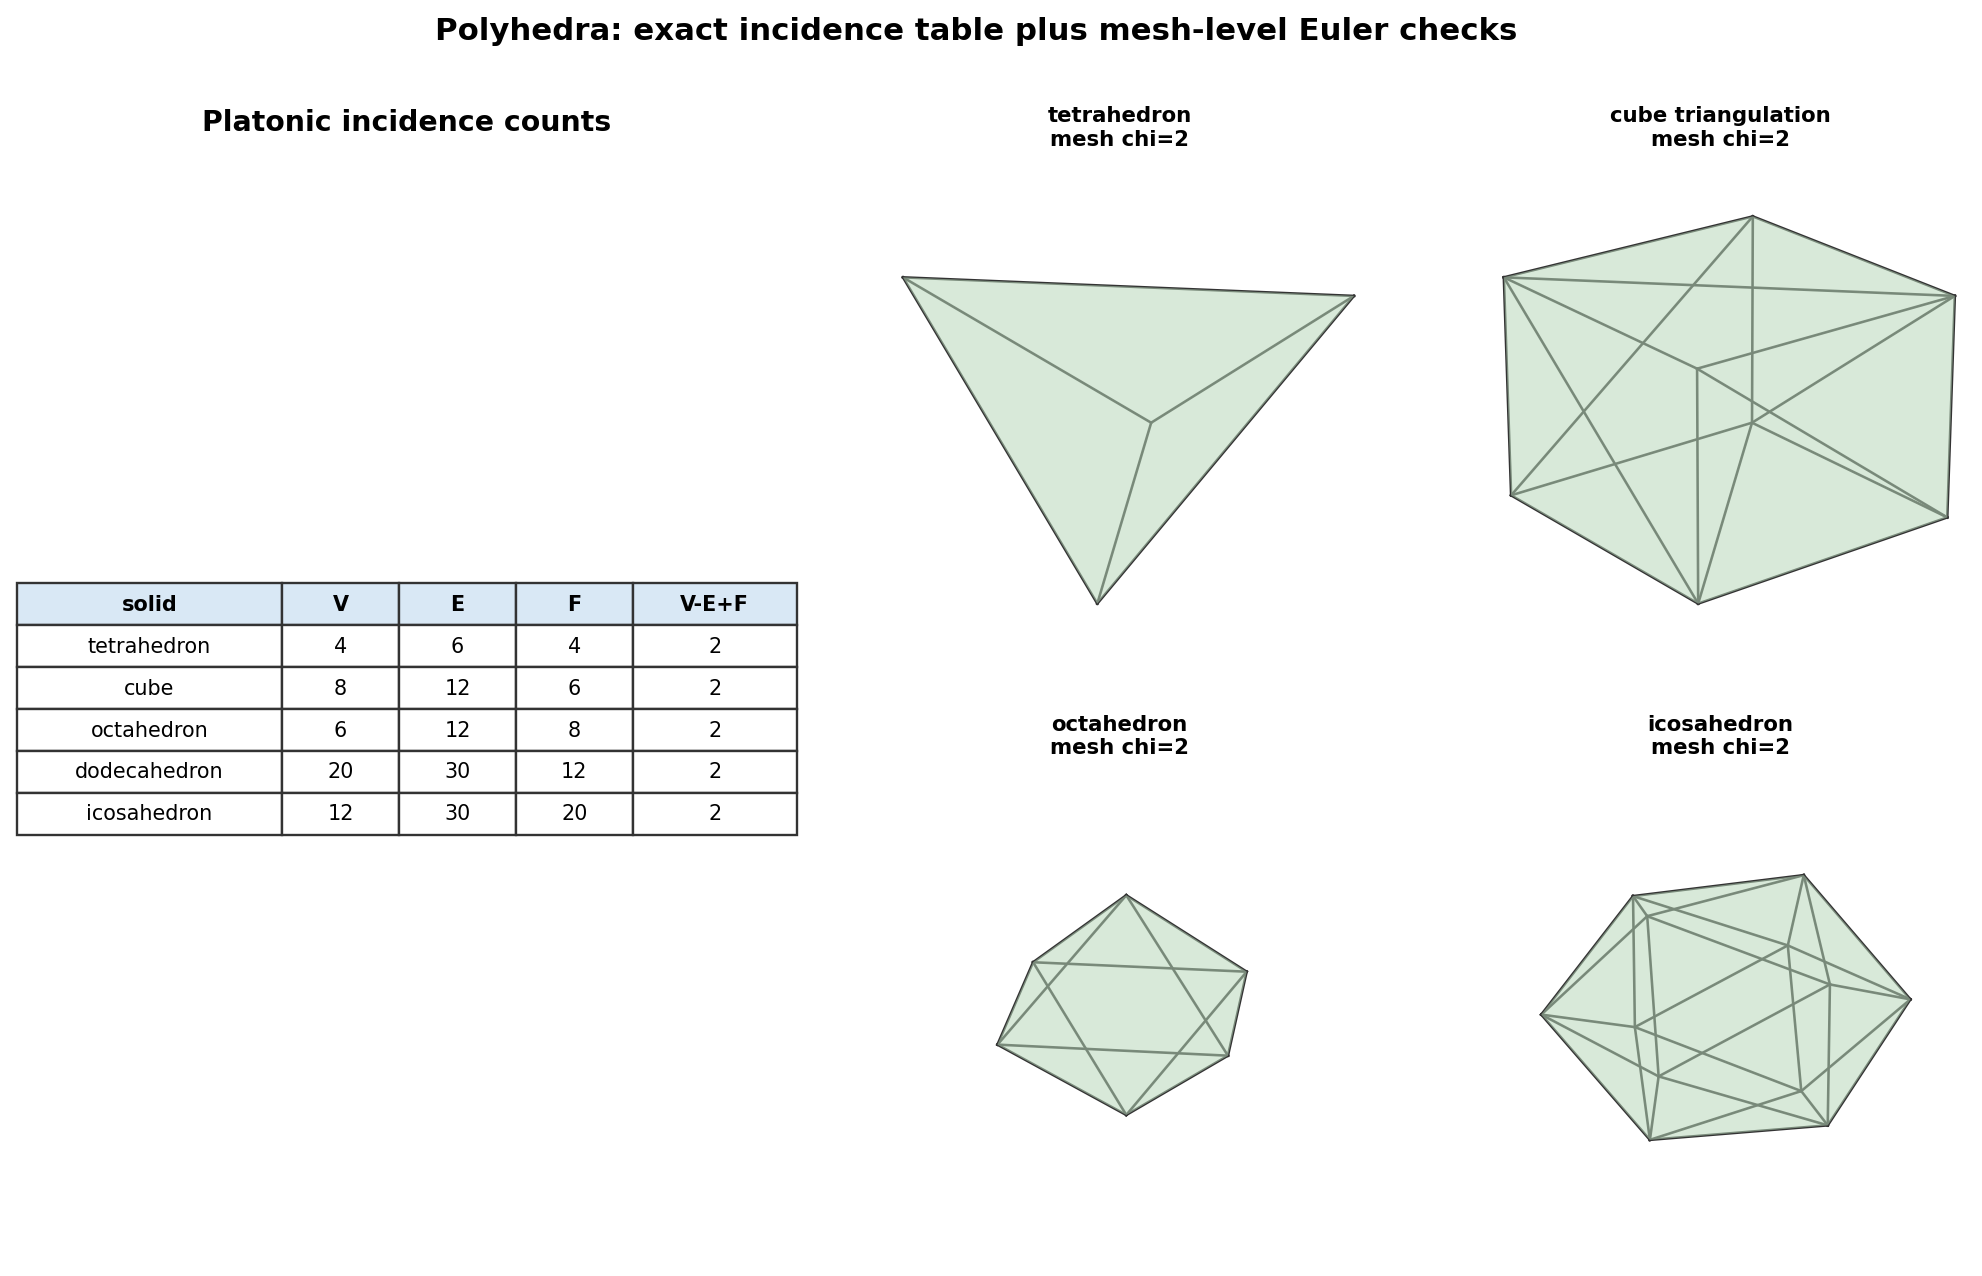

,solid,vertices,edges,faces,face_type,euler_characteristic
0,tetrahedron,4,6,4,triangle,2
1,cube,8,12,6,square,2
2,octahedron,6,12,8,triangle,2
3,dodecahedron,20,30,12,pentagon,2
4,icosahedron,12,30,20,triangle,2


In [7]:
platonic_rows = [
    {"solid": "tetrahedron", "vertices": 4, "edges": 6, "faces": 4, "face_type": "triangle"},
    {"solid": "cube", "vertices": 8, "edges": 12, "faces": 6, "face_type": "square"},
    {"solid": "octahedron", "vertices": 6, "edges": 12, "faces": 8, "face_type": "triangle"},
    {"solid": "dodecahedron", "vertices": 20, "edges": 30, "faces": 12, "face_type": "pentagon"},
    {"solid": "icosahedron", "vertices": 12, "edges": 30, "faces": 20, "face_type": "triangle"},
]
platonic_table = pd.DataFrame(platonic_rows)
platonic_table["euler_characteristic"] = platonic_table["vertices"] - platonic_table["edges"] + platonic_table["faces"]

tetra_vertices = np.array([[1, 1, 1], [-1, -1, 1], [-1, 1, -1], [1, -1, -1]], dtype=float)
tetra_faces = np.array([[0, 1, 2], [0, 3, 1], [0, 2, 3], [1, 3, 2]])
tetra_mesh = trimesh.Trimesh(vertices=tetra_vertices, faces=tetra_faces, process=True)
octa_vertices = np.array([[1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, 1], [0, 0, -1]], dtype=float)
octa_faces = np.array([[0, 2, 4], [2, 1, 4], [1, 3, 4], [3, 0, 4], [2, 0, 5], [1, 2, 5], [3, 1, 5], [0, 3, 5]])
octa_mesh = trimesh.Trimesh(vertices=octa_vertices, faces=octa_faces, process=True)
mesh_examples = {
    "tetrahedron": tetra_mesh,
    "cube triangulation": trimesh.creation.box(extents=(1.6, 1.6, 1.6)),
    "octahedron": octa_mesh,
    "icosahedron": trimesh.creation.icosahedron(),
}
mesh_rows = []
for name, mesh in mesh_examples.items():
    mesh_rows.append({
        "mesh": name,
        "mesh_vertices": int(len(mesh.vertices)),
        "mesh_edges": int(len(mesh.edges_unique)),
        "mesh_faces": int(len(mesh.faces)),
        "mesh_euler_number": int(mesh.euler_number),
        "watertight": bool(mesh.is_watertight),
    })
mesh_table = pd.DataFrame(mesh_rows)

fig = plt.figure(figsize=(14.6, 8.4))
grid = fig.add_gridspec(2, 3, width_ratios=[1.45, 1, 1], height_ratios=[1, 1], wspace=0.18, hspace=0.24)
ax_table = fig.add_subplot(grid[:, 0])
ax_table.axis("off")
cell_text = platonic_table[["solid", "vertices", "edges", "faces", "euler_characteristic"]].values.tolist()
table = ax_table.table(cellText=cell_text, colLabels=["solid", "V", "E", "F", "V-E+F"], cellLoc="center", loc="center", colWidths=[0.34, 0.15, 0.15, 0.15, 0.21])
table.auto_set_font_size(False)
table.set_fontsize(8.8)
table.scale(1.08, 1.48)
for key, cell in table.get_celld().items():
    cell.set_edgecolor("#333333")
    if key[0] == 0:
        cell.set_facecolor("#d9e8f5")
        cell.set_text_props(weight="bold")
ax_table.set_title("Platonic incidence counts", pad=12)

for idx, (name, mesh) in enumerate(mesh_examples.items()):
    ax = fig.add_subplot(grid[idx // 2, 1 + idx % 2], projection="3d")
    vertices = np.asarray(mesh.vertices)
    for edge in mesh.edges_unique:
        pts = vertices[edge]
        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color="#333333", linewidth=1.1)
    collection = Poly3DCollection(vertices[mesh.faces], facecolor="#b8d8ba", edgecolor="none", alpha=0.32)
    ax.add_collection3d(collection)
    scale = max(np.ptp(vertices[:, 0]), np.ptp(vertices[:, 1]), np.ptp(vertices[:, 2])) / 2
    center = vertices.mean(axis=0)
    ax.set_xlim(center[0] - scale, center[0] + scale)
    ax.set_ylim(center[1] - scale, center[1] + scale)
    ax.set_zlim(center[2] - scale, center[2] + scale)
    ax.set_title(f"{name}\nmesh chi={int(mesh.euler_number)}", fontsize=9)
    ax.set_axis_off()
    ax.view_init(elev=22, azim=-38)
fig.suptitle("Polyhedra: exact incidence table plus mesh-level Euler checks", y=0.98, fontsize=13, weight="bold")
polyhedra_path = save_figure(fig, "polyhedra-euler-dashboard.png")
artifacts["polyhedra_euler_dashboard"] = polyhedra_path

platonic_csv = TABLE_DIR / "platonic-euler-counts.csv"
mesh_csv = TABLE_DIR / "polyhedra-mesh-diagnostics.csv"
platonic_table.to_csv(platonic_csv, index=False)
mesh_table.to_csv(mesh_csv, index=False)
artifacts["platonic_counts_table"] = platonic_csv
artifacts["mesh_diagnostics_table"] = mesh_csv
polyhedra_check = {
    "platonic_solids_checked": platonic_table["solid"].tolist(),
    "all_platonic_euler_characteristics_equal_2": bool((platonic_table["euler_characteristic"] == 2).all()),
    "mesh_examples_checked": mesh_table["mesh"].tolist(),
    "all_mesh_euler_numbers_equal_2": bool((mesh_table["mesh_euler_number"] == 2).all()),
    "all_meshes_watertight": bool(mesh_table["watertight"].all()),
}
check_data["polyhedra"] = polyhedra_check
write_json(polyhedra_check, "polyhedra-checks.json")
display_artifact(polyhedra_path, width=980)
platonic_table

## Applied Lab: Audit a Miniature Geometry Curriculum

Use this lab as a quick rehearsal for the rest of the book. Each row names a theme from the Introduction, the object we used to make it visible, and the invariant that would fail first if the model were changed carelessly. Try changing one parameter in an earlier cell, then rerun the final sanity cell to see which invariant catches the change.

In [8]:
lab_rows = [
    {
        "theme": "construction",
        "artifact": book_relative(artifacts["construction_assumption"]),
        "inspect": "circle intersection and dependency graph",
        "sanity_invariant": "AB = AC = BC",
        "current_value": construction_check["all_three_lengths_equal"],
    },
    {
        "theme": "axioms",
        "artifact": book_relative(artifacts["course_map"]),
        "inspect": "arrows from proof gaps to model-building",
        "sanity_invariant": "all required course topics reachable from Euclid",
        "current_value": course_check["all_topics_reachable_from_euclid"],
    },
    {
        "theme": "coordinates and fields",
        "artifact": book_relative(artifacts["constructibility_ladder"]),
        "inspect": "power-of-two degree ladder",
        "sanity_invariant": "17-gon passes while 7-gon fails",
        "current_value": constructibility_check["regular_17_gon_constructible"] and not constructibility_check["regular_7_gon_constructible"],
    },
    {
        "theme": "area",
        "artifact": book_relative(artifacts["area_invariant"]),
        "inspect": "two smaller square areas versus the hypotenuse square",
        "sanity_invariant": "9 + 16 = 25",
        "current_value": area_check["area_identity_holds"],
    },
    {
        "theme": "hyperbolic geometry",
        "artifact": book_relative(artifacts["poincare_parallel_family"]),
        "inspect": "geodesics through P avoiding a fixed geodesic",
        "sanity_invariant": "orthogonality residual is near zero",
        "current_value": hyperbolic_check["max_orthogonality_residual"] < 1e-12,
    },
    {
        "theme": "polyhedra",
        "artifact": book_relative(artifacts["polyhedra_euler_dashboard"]),
        "inspect": "V, E, F counts and triangulated mesh diagnostics",
        "sanity_invariant": "Euler characteristic equals 2",
        "current_value": polyhedra_check["all_platonic_euler_characteristics_equal_2"] and polyhedra_check["all_mesh_euler_numbers_equal_2"],
    },
]
lab_table = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / "applied-lab-audit.csv"
lab_table.to_csv(lab_path, index=False)
artifacts["applied_lab_audit"] = lab_path
lab_table

,theme,artifact,inspect,sanity_invariant,current_value
0,construction,artifacts/introduction/figures/equilateral-con...,circle intersection and dependency graph,AB = AC = BC,True
1,axioms,artifacts/introduction/figures/course-roadmap.png,arrows from proof gaps to model-building,all required course topics reachable from Euclid,True
2,coordinates and fields,artifacts/introduction/figures/constructibilit...,power-of-two degree ladder,17-gon passes while 7-gon fails,True
3,area,artifacts/introduction/figures/area-as-invaria...,two smaller square areas versus the hypotenuse...,9 + 16 = 25,True
4,hyperbolic geometry,artifacts/introduction/interactive/poincare-pa...,geodesics through P avoiding a fixed geodesic,orthogonality residual is near zero,True
5,polyhedra,artifacts/introduction/figures/polyhedra-euler...,"V, E, F counts and triangulated mesh diagnostics",Euler characteristic equals 2,True


## Takeaways

- The Introduction is a route map from Euclid's construction practice to modern foundations and models.
- A construction is not fully computational until its allowed operations and existence predicates are visible.
- Coordinates and fields do not replace synthetic geometry; they expose algebraic invariants that can be checked.
- Area and volume questions are not just measurement questions. They are also decomposition and invariance questions.
- Hyperbolic geometry becomes concrete once the parallel postulate is tested inside a model.
- Polyhedra connect the visual course to finite incidence data, mesh diagnostics, and Euler characteristic.

## Final Sanity Checks

The final cell checks the notebook's own promises: required artifacts exist and are nontrivial, exact symbolic identities still hold, saved tables have rows, model residuals are small, and the course-arc topics from the source span are all represented.

In [9]:
artifact_min_bytes = {
    "course_map": 10_000,
    "construction_assumption": 10_000,
    "constructibility_ladder": 10_000,
    "constructibility_table": 80,
    "area_invariant": 10_000,
    "poincare_parallel_family": 50_000,
    "polyhedra_euler_dashboard": 10_000,
    "platonic_counts_table": 80,
    "mesh_diagnostics_table": 80,
    "applied_lab_audit": 80,
}
artifact_sizes = {}
for key, min_bytes in artifact_min_bytes.items():
    checked = assert_artifact(artifacts[key], min_bytes=min_bytes)
    artifact_sizes[key] = checked.stat().st_size

assert course_check["all_required_topics_present"]
assert course_check["all_topics_reachable_from_euclid"]
assert construction_check["all_three_lengths_equal"]
assert construction_check["circle_intersection_condition"]
assert constructibility_check["regular_17_gon_constructible"]
assert not constructibility_check["regular_7_gon_constructible"]
assert area_check["area_identity_holds"]
assert hyperbolic_check["max_orthogonality_residual"] < 1e-12
assert hyperbolic_check["all_arcs_avoid_fixed_diameter_in_disk"]
assert polyhedra_check["all_platonic_euler_characteristics_equal_2"]
assert polyhedra_check["all_mesh_euler_numbers_equal_2"]
assert len(lab_table) == 6

final_sanity = {
    "unit": UNIT,
    "source_span": "printed pp. 1-6 / PDF pp. 13-18",
    "artifact_count": len(artifact_sizes),
    "artifact_sizes": artifact_sizes,
    "checks": check_data,
    "lab_rows": int(len(lab_table)),
    "required_arc_topics": sorted(required_topics),
}
final_sanity_path = write_json(final_sanity, "final-sanity.json")
notebook_sanity_path = write_json(final_sanity, "notebook-sanity.json")
artifacts["final_sanity"] = final_sanity_path
artifacts["notebook_sanity"] = notebook_sanity_path
assert_artifact(final_sanity_path, min_bytes=500)
assert_artifact(notebook_sanity_path, min_bytes=500)
visual_check_path = write_json({
    "unit": UNIT,
    "visual_artifacts": {key: book_relative(path) for key, path in artifacts.items() if key not in {"final_sanity", "notebook_sanity"}},
    "core_checks_passed": True,
}, "visual-checks.json")
assert_artifact(visual_check_path, min_bytes=250)
final_sanity


{'unit': 'introduction',
 'source_span': 'printed pp. 1-6 / PDF pp. 13-18',
 'artifact_count': 10,
 'artifact_sizes': {'course_map': 170393,
  'construction_assumption': 156523,
  'constructibility_ladder': 140694,
  'constructibility_table': 340,
  'area_invariant': 45685,
  'poincare_parallel_family': 4994398,
  'polyhedra_euler_dashboard': 226721,
  'platonic_counts_table': 208,
  'mesh_diagnostics_table': 187,
  'applied_lab_audit': 966},
 'checks': {'course_map': {'node_count': 8,
   'edge_count': 10,
   'required_topics_present': ['Area',
    'Axioms and gaps',
    'Constructibility',
    'Coordinates and fields',
    "Euclid's Elements",
    'Hyperbolic geometry',
    'Polyhedra',
    'Ruler and compass'],
   'all_required_topics_present': True,
   'all_topics_reachable_from_euclid': True},
  'construction_assumption': {'lengths': {'AB': '1', 'AC': '1', 'BC': '1'},
   'all_three_lengths_equal': True,
   'circle_intersection_condition': True,
   'dependency_nodes': 8,
   'depende